#Project mnistDigit

In [63]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping


###Definition

In [64]:
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()

In [46]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


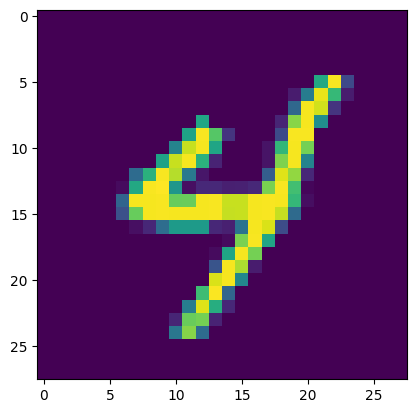

In [81]:
plt.imshow(X_train[115])


###Normalization

In [66]:
X_train,X_test=X_train/255,X_test/255

#  چرا توی نرمال سازی فقط ضریب های x را نرمال میکنیم ؟
# X_train,X_test=X_train/255,x_test/255
# چون در MNIST:
# X → ویژگی‌ها (features) یعنی خود پیکسل‌های تصویر هستند (عدد شدت روشنایی 0 تا 255)
# y → برچسب (label) یعنی عدد 0 تا 9 است


###Model

In [67]:
len(np.unique(y_train))
# مشاهده تعداد خروجی در مدل طبقه بندی و قرار دادن ان در تعداد نورون خروجی در لایه اخر

10

In [68]:
model = keras.models.Sequential(
    [
    keras.layers.Flatten(input_shape=[28,28]),
    keras.layers.Dense(10,activation="selu"),
    keras.layers.Dense(10,activation="softmax"),
    ]
 )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [51]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,960 (31.09 KB)

 Trainable params: 7,960 (31.09 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
weight,bias= model.layers[2].get_weights()
print(weight.shape)
print(bias.shape)

(10, 10)
(10,)


###compile

In [70]:
model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
        )

####EarlyStopping

In [69]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [71]:
history1 = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=24,
    validation_split=0.2,
    callbacks=[early_stop]

)

Epoch 1/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8700 - loss: 0.4748 - val_accuracy: 0.9175 - val_loss: 0.2964
Epoch 2/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9159 - loss: 0.2958 - val_accuracy: 0.9197 - val_loss: 0.2791
Epoch 3/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9229 - loss: 0.2726 - val_accuracy: 0.9287 - val_loss: 0.2530
Epoch 4/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9258 - loss: 0.2594 - val_accuracy: 0.9289 - val_loss: 0.2566
Epoch 5/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9294 - loss: 0.2484 - val_accuracy: 0.9325 - val_loss: 0.2452
Epoch 6/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9319 - loss: 0.2393 - val_accuracy: 0.9326 - val_loss: 0.2422
Epoch 7/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9339 - loss: 0.2324 - val_accuracy: 0.9308 - val_loss: 0.2409
Epoch 8/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9370 - loss: 0.2251 - 

###trainingPerformance

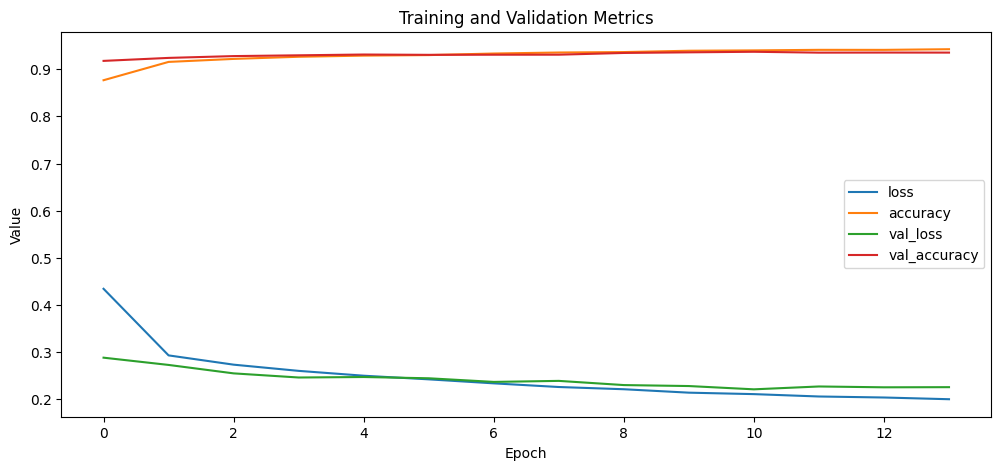

In [96]:

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history.history['loss'], label='loss')
ax.plot(history.history['accuracy'], label='accuracy')
ax.plot(history.history['val_loss'], label='val_loss')
ax.plot(history.history['val_accuracy'], label='val_accuracy')

ax.set_xlabel('Epoch')
ax.set_ylabel('Value')
ax.set_title('Training and Validation Metrics')
ax.legend()
plt.show()

### testModel

In [72]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9416 - loss: 0.2063


[0.20634013414382935, 0.9416000247001648]

In [91]:
pred = model.predict(X_test[400:450])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step


In [92]:
np.argmax(pred, axis=1)

array([2, 8, 3, 9, 2, 4, 5, 0, 3, 1, 7, 7, 3, 7, 9, 7, 1, 9, 2, 1, 4, 2,
       9, 2, 0, 4, 9, 1, 4, 8, 1, 8, 4, 5, 9, 7, 8, 3, 7, 6, 0, 0, 3, 0,
       2, 0, 6, 4, 9, 3])

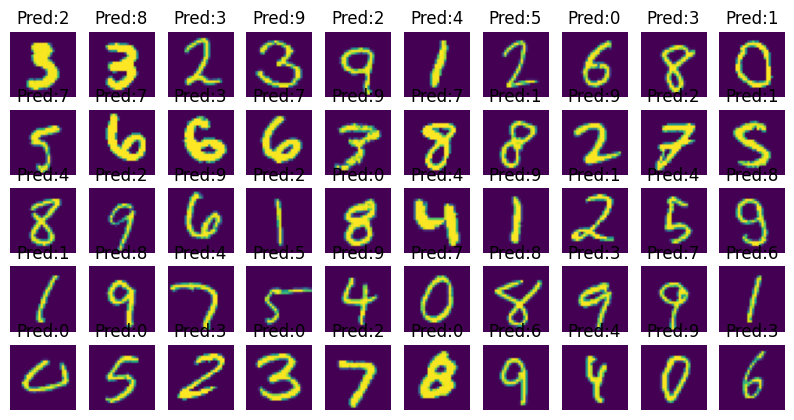

In [94]:

plt.figure(figsize=(10,10))

for i in range(50):
    plt.subplot(10,10,i+1)
    plt.imshow(X_test[450+i])
    plt.title(f"Pred:{np.argmax(pred[i])}")
    plt.axis("off")

plt.show()